In [2]:
from tavi.library.Instrument.instrument import Instrument, InstrumentCatalog
from tavi.library.experiment.experiment import Experiment
from tavi.library.experiment.utilities import mantid_to_spice
from tavi.library.tas.triple_axis import TAS
from tavi.library.fit import ModelName
from pathlib import Path
import numpy as np


# Set up for Hb3. 
The spice_ub is read from a .ini file from UBConf. Sample mosaic can be tuned mannually. Lattice information would need to be input by hand.

In [5]:
from tavi.library.experiment.utilities import spice_to_mantid
from tavi.library.geometry.oriented_lattice import OrientedLattice
from tavi.library.geometry.sample import Sample

experiment = Experiment()
ol = OrientedLattice(a=4.938669, b =4.938669, c = 13.592861, alpha=90, beta = 90, gamma = 120)
spice_ub = np.array([[-0.144255,-0.072128,-0.057896],
                     [0.184002,0.092001,-0.045390],
                     [0.000000,-0.202484,-0.000000]])
ol.UB = spice_to_mantid(spice_ub, version="old")
sample = Sample(ol)
sample.mosaic_h = 35
sample.mosaic_v = 35
tas = TAS(Instrument(instrument_catalog=InstrumentCatalog.HB3), sample, experiment)
datafiles = Path.cwd().parent.joinpath("test_data","IPTS-35115", "exp861", "Datafiles")
tas.experiment.load_folder(datafiles)

# Select one or many scans to simply browse the data.

incoherent FWHM =  [(np.float64(0.07817324158814315),)]


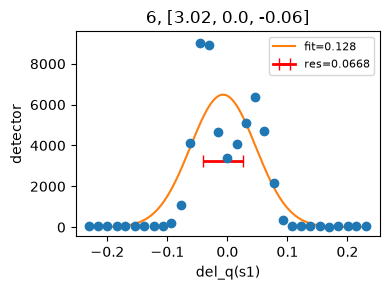

In [6]:
elastic_peak = [6]
_=tas.browse(elastic_peak,show_fits=True, model_dict = [(ModelName.Gaussian, dict(guess = True))], show_resolution_bar=True, projection_axis=0)

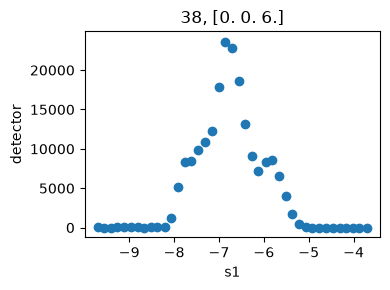

(None, None, None)

In [4]:
elastic_peak = [38]
tas.browse(elastic_peak,show_fits=False)

# Example of showing fitting the peak with 3 Gaussian functions and a linear background.

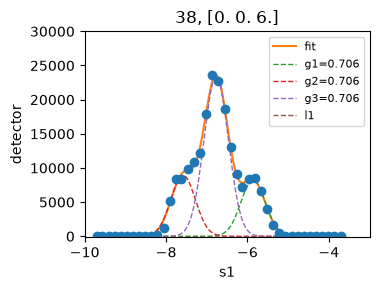

In [5]:
hkls, fit_results, res_4ds = tas.browse(elastic_peak, 
                                        show_fits=True, 
                                        model_dict=[
                                                (ModelName.Gaussian, dict(prefix="g1_", center=-7.7, sigma=0.3, amplitude=500,
                                                                          set = {"center": dict(vary = True), "sigma": dict(vary = False), "amplitude":dict(vary = True)})),
                                                (ModelName.Gaussian, dict(prefix="g2_", center=-6.7, sigma=0.3, amplitude=750,
                                                                          set = {"center": dict(vary = True),"sigma": dict(vary = False), "amplitude":dict(vary = True)})),
                                                (ModelName.Gaussian, dict(prefix="g3_", center=-5.7, sigma=0.3, amplitude=500,
                                                                          set = {"center": dict(vary = True),"sigma": dict(vary = False),"amplitude": dict(vary = True)})),
                                                (ModelName.Linear, dict(
                                                    prefix="l1_",
                                                    slope=0,
                                                    intercept=0,
                                                    set = {"slope": dict(vary = True),"intercept": dict(vary = True)})),
                                            ],
                                        show_resolution_bar=False,
                                        show_components=True,
                                        xlim = [-10, -3],
                                        ylim = [-100, 30000])

# Example of fitting the same peak but with "show_resolution_bar = True" turned on.
This automatically transforms s1 axis to delta_q axis since resolution is only calculated in q-space. "show_components" key word can be turned on to show each individual fitted line.

incoherent FWHM =  [(np.float64(0.11565545700564255), np.float64(0.11565552607503832), np.float64(0.11565559536387844))]


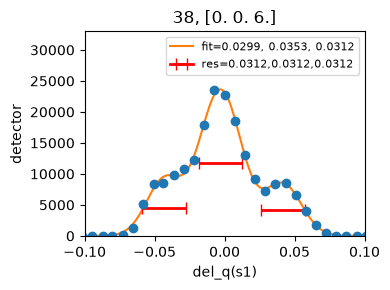

In [6]:
hkls, fit_results, res_4ds = tas.browse(elastic_peak, 
                                        show_fits=True, 
                                        model_dict=[
                                                (ModelName.Gaussian, dict(prefix="g1_", center=-0.05, sigma=0.015, amplitude=500,
                                                                          set = {"center": dict(vary = True), "sigma": dict(vary = True), "amplitude":dict(vary = True)})),
                                                (ModelName.Gaussian, dict(prefix="g2_", center=0, sigma=0.015, amplitude=750,
                                                                          set = {"center": dict(vary = True),"sigma": dict(vary = True), "amplitude":dict(vary = True)})),
                                                (ModelName.Gaussian, dict(prefix="g3_", center=0.035, sigma=0.015, amplitude=500,
                                                                          set = {"center": dict(vary = True),"sigma": dict(vary = True),"amplitude": dict(vary = True)})),
                                                (ModelName.Linear, dict(
                                                    prefix="l1_",
                                                    slope=0,
                                                    intercept=0,
                                                    set = {"slope": dict(vary = False),"intercept": dict(vary = False)})),
                                            ],
                                        show_resolution_bar=True,
                                        show_components=False,
                                        projection_axis=1,
                                        xlim = [-0.1, 0.1],
                                        ylim = [-100, 33000])

# Optional to check ub matrix are correct.

In [7]:
# from tavi.library.experiment.peak import DataPoint, MotorAngles

# peaks = [
#     DataPoint(hkl=(0.0, 0.0, 6.0), ei=14.7002, ef=14.7013, angles=MotorAngles(angles_dict={'two_theta': 62.750169, 'omega': -6.725000, 'sgl': 0.0, 'sgu': -0.0})), 
#     DataPoint(hkl=(3.0, 0.0, 0.0), ei=14.7002, ef=14.699900000000001, angles=MotorAngles(angles_dict={'two_theta': 111.650957, 'omega': 108.105000, 'sgl': 0.0, 'sgu': -0.0}))
# ]

# print(f"Compare \n {np.round(mantid_to_spice(tas.ub(peaks = peaks, reset_ub=False), version="old"),6)} \n with data.")
# print(mantid_to_spice(sample.ol.UB, version = "old"))

# Browse several inelastic scans.

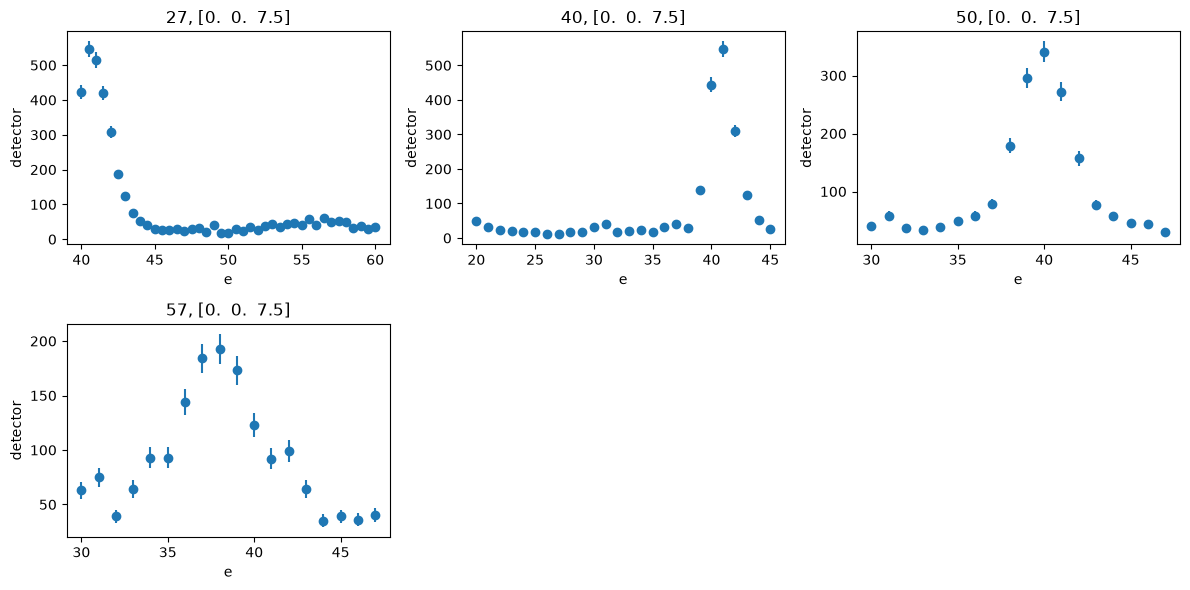

(None, None, None)

In [8]:
scan_list = list([27,40,50,57])
tas.browse(scan_list, show_fits = False)

# Fit the inelastic scans and show the resolution bar. 

"resolution_frame" need to be set properly. Example here shows the sample is in H0L scattering plane, 1st axis is H(1, 0, 0), 2nd axis is L(0,0,1). 3rd axis is out-of-plane K(0,1,0), energy is always fourth axis represented by "e".

Projection axis (0-indexed) corresponds to the defined reference_frame. Here the data is plotted along "e" so projection axis is 3. 

Projection axis 0 -> H, 1->L, 2->K, 3->e based on "resolution_frame" set up.

Resolution bar shows coherent resolution(FWHM), incoherent resolution is printed below.

incoherent FWHM =  [(np.float64(5.035423465606379),), (np.float64(5.101537574322553),), (np.float64(4.9694175687282),), (np.float64(4.70900900734317),)]


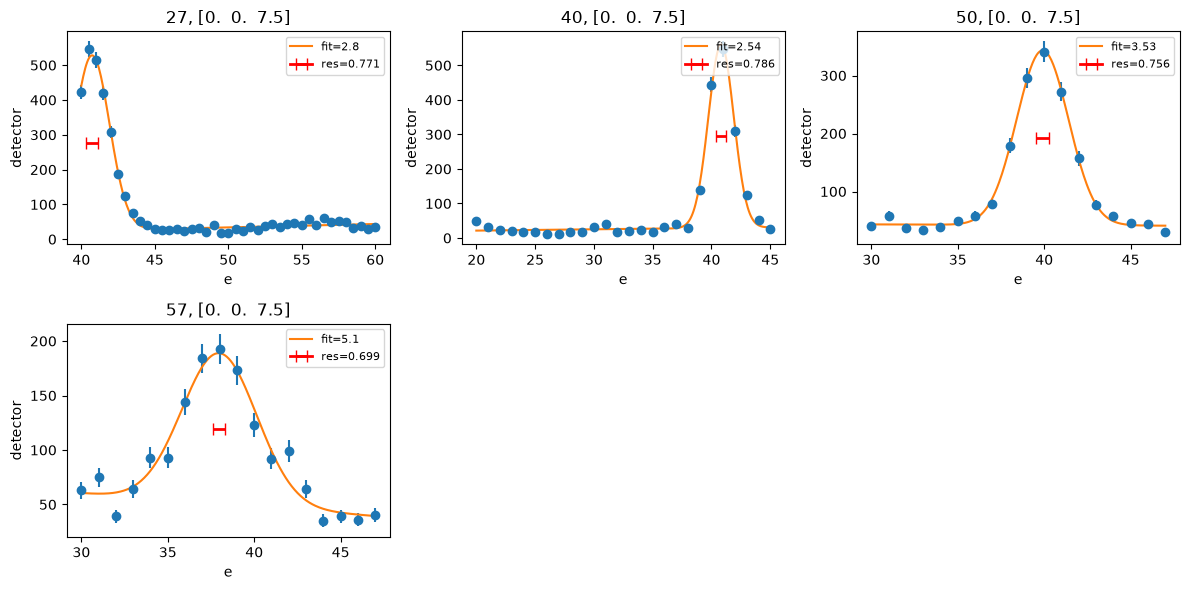

In [9]:
_=tas.browse(scan_list, 
                                        show_fits=True, 
                                        model_dict=[(ModelName.Gaussian, dict(prefix="g",guess = True)),
                                                    (ModelName.Linear, dict(prefix="l",guess=True))], 
                                        show_resolution_bar=True,
                                        show_components=False,
                                        resolution_frame=((1, 0, 0), (0, 0, 1), (0, 1, 0), "e"),
                                        projection_axis=3,
                                        )

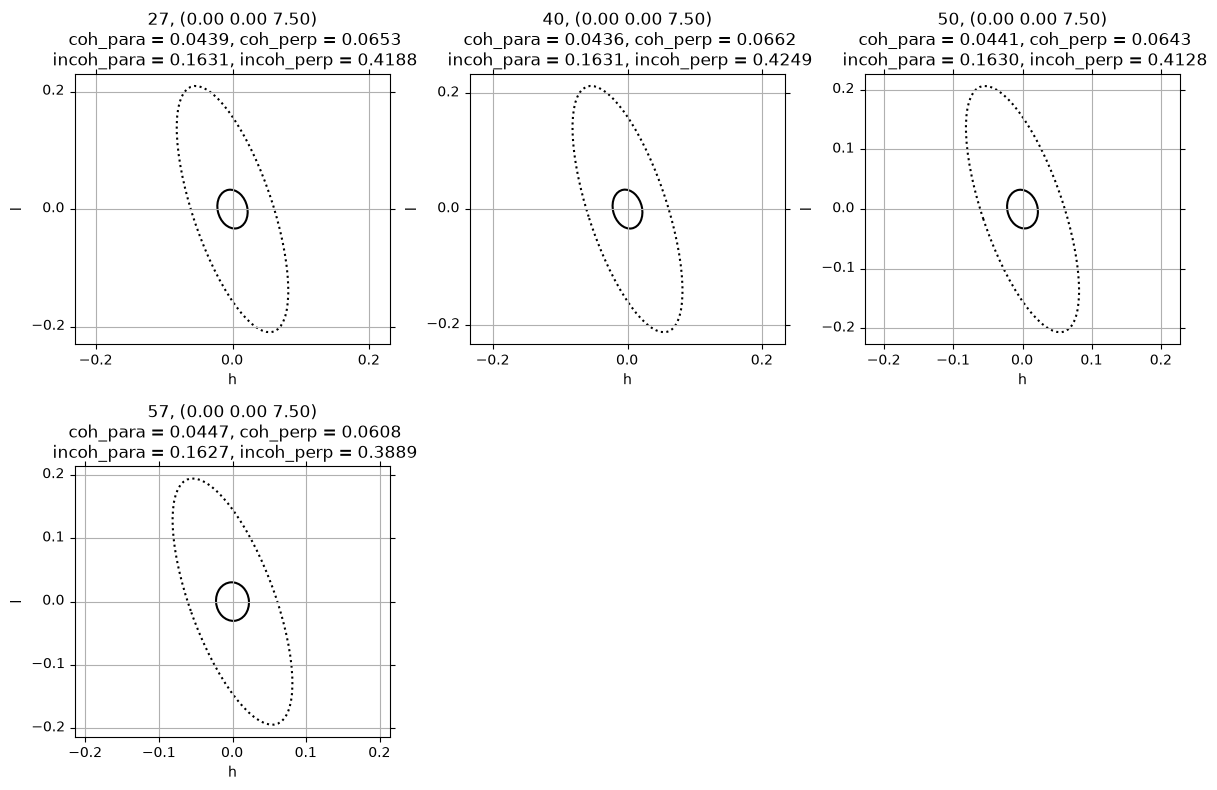

In [10]:
tas.browse_resolution_ellipse(scan_list, xlabel="h", ylabel="l", resolution_frame=((1, 0, 0), (0, 0, 1), (0, 1, 0), "e"),ellipse_axes=(0, 1))